In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [ ]:
svs = pd.read_csv('../../data/cmi_cohort/cmi_consensus_sv_class_annotated.tsv', sep='\t')
print("Total SVs: ", len(svs))
svs.head()

Total SVs:  2230


,chr1,pos1,chr2,pos2,span,ref,alt1,alt2,svtype,sample,control_AD,control_DP,tumor_AD,tumor_DP
0,1,2523852,1,2524048,196,G,G[1:2524048[,]1:2523852]C,DEL,OSPECGS_P2JL3K_BLOOD_2,0,25,28,41
1,1,8734089,1,8737387,3298,T,T[1:8737387[,]1:8734089]C,DEL,OSPECGS_P2JL3K_BLOOD_2,0,56,15,84
2,1,9121449,14,93712482,-1,C,[14:93712482[C,[1:9121449[A,TRA,OSPECGS_P2JL3K_BLOOD_2,0,24,6,73
3,1,38241383,19,11422016,-1,C,]19:11422016]C,T[1:38241383[,TRA,OSPECGS_P2JL3K_BLOOD_2,0,26,25,70
4,1,46711933,10,120769130,-1,A,A]10:120769130],T]1:46711933],TRA,OSPECGS_P2JL3K_BLOOD_2,0,27,12,48


In [3]:
svs['sample'].value_counts()

sample
OSPECGS_PG2LWL_BLOOD      303
OSPECGS_PRKEDP_BLOOD      266
OSPECGS_PHQJ9R_BLOOD      247
OSPECGS_PKF9WN_BLOOD      240
OSPECGS_PAAR6B_BLOOD      224
OSPECGS_PNPVG4_BLOOD      218
OSPECGS_PEYBG7_BLOOD      202
OSPECGS_PYRMQX_BLOOD_2    181
OSPECGS_PN2YYT_BLOOD      176
OSPECGS_P2JL3K_BLOOD_2    173
Name: count, dtype: int64

In [ ]:
# remove exact duplicates (by chr1, pos1, chr2, pos2, span, svtype)
svs = svs.drop_duplicates(subset=['chr1', 'pos1', 'chr2', 'pos2', 'span', 'svtype', 'sample'])
svs.to_csv('../../data/cmi_cohort/cmi_consensus_sv_class_annotated.tsv', sep='\t', index=False)
print(len(svs))

2230


In [ ]:
# create BED file of filtered SVs (keep chr, start, end, SV ID) for convertion to hg38 coordinates (gnomAD current version uses hg38)

# Add a unique SV index
svs['sv_index'] = range(len(svs))

# Create breakpoint 1 entries (chr1, pos1)
bp1 = pd.DataFrame({
    'chrom': 'chr' + svs['chr1'].astype(str),
    'start': svs['pos1'] - 1,
    'end': svs['pos1'],
    'name': 'SV' + svs['sv_index'].astype(str) + '_BP1_' + svs['sample']
})

# Create breakpoint 2 entries (chr2, pos2)
bp2 = pd.DataFrame({
    'chrom': 'chr' + svs['chr2'].astype(str),
    'start': svs['pos2'] - 1,
    'end': svs['pos2'],
    'name': 'SV' + svs['sv_index'].astype(str) + '_BP2_' + svs['sample']
})

breakpoints_bed = pd.concat([bp1, bp2], ignore_index=True)
breakpoints_bed = breakpoints_bed.sort_values(['chrom', 'start'])

print(f"Total SVs: {len(svs)}")
print(f"Total breakpoints: {len(breakpoints_bed)}")

# Save as BED (w/ no header for liftOver)
breakpoints_bed.to_csv('../../data/cmi_cohort/sv_breakpoints_pre_liftover.bed', sep='\t', index=False, header=False)
breakpoints_bed.head(10)

Total SVs: 2230
Total breakpoints: 4460


,chrom,start,end,name
173,chr1,1865699,1865700,SV173_BP1_OSPECGS_PAAR6B_BLOOD
2403,chr1,1866239,1866240,SV173_BP2_OSPECGS_PAAR6B_BLOOD
599,chr1,1900578,1900579,SV599_BP1_OSPECGS_PG2LWL_BLOOD
2829,chr1,1900769,1900770,SV599_BP2_OSPECGS_PG2LWL_BLOOD
0,chr1,2523851,2523852,SV0_BP1_OSPECGS_P2JL3K_BLOOD_2
600,chr1,2523851,2523852,SV600_BP1_OSPECGS_PG2LWL_BLOOD
1149,chr1,2523851,2523852,SV1149_BP1_OSPECGS_PKF9WN_BLOOD
1389,chr1,2523851,2523852,SV1389_BP1_OSPECGS_PN2YYT_BLOOD
1565,chr1,2523851,2523852,SV1565_BP1_OSPECGS_PNPVG4_BLOOD
2230,chr1,2524047,2524048,SV0_BP2_OSPECGS_P2JL3K_BLOOD_2


In [ ]:
# Load the lifted BED file (https://genome.ucsc.edu/cgi-bin/hgLiftOver)
lifted = pd.read_csv('../../data/cmi_cohort/hglft_genome_315fda_2adf80.bed', sep='\t', header=None, names=['chrom', 'start', 'end', 'name', 'fragment'])

# Parse the name column: {SVindex}_BP{1or2}_{sample}
lifted['sv_index'] = lifted['name'].str.extract(r'SV(\d+)_')[0].astype(int)
lifted['breakpoint'] = lifted['name'].str.extract(r'_BP(\d)_')[0].astype(int)
lifted['sample'] = lifted['name'].str.replace(r'SV\d+_BP\d_', '', regex=True)

# Convert to 1-based position (BED is 0-based, add 1 to start)
lifted['pos'] = lifted['end']

print(f"Total lifted breakpoints: {len(lifted)}")

# Separate BP1 and BP2
bp1 = lifted[lifted['breakpoint'] == 1][['sv_index', 'sample', 'chrom', 'pos']].copy()
bp1.columns = ['sv_index', 'sample', 'chr1', 'pos1']

bp2 = lifted[lifted['breakpoint'] == 2][['sv_index', 'sample', 'chrom', 'pos']].copy()
bp2.columns = ['sv_index', 'sample', 'chr2', 'pos2']

# Merge to reconstruct SVs
reconstructed = pd.merge(bp1, bp2, on=['sv_index', 'sample'], how='outer', indicator=True)

# Identify complete SVs (both breakpoints lifted)
complete_svs = reconstructed[reconstructed['_merge'] == 'both'].drop(columns='_merge')

# Identify SVs with missing partner
bp1_only = reconstructed[reconstructed['_merge'] == 'left_only'][['sv_index', 'sample', 'chr1', 'pos1']]
bp2_only = reconstructed[reconstructed['_merge'] == 'right_only'][['sv_index', 'sample', 'chr2', 'pos2']]

print(f"Complete SVs (both breakpoints lifted): {len(complete_svs)}")
print(f"SVs with only BP1 lifted (BP2 failed): {len(bp1_only)}")
print(f"SVs with only BP2 lifted (BP1 failed): {len(bp2_only)}")

complete_svs['chr1'] = complete_svs['chr1'].str.replace('chr', '')
complete_svs['chr2'] = complete_svs['chr2'].str.replace('chr', '')
complete_svs['pos1'] = complete_svs['pos1'].astype(int) 
complete_svs['pos2'] = complete_svs['pos2'].astype(int)

complete_svs = complete_svs[['chr1', 'pos1', 'chr2', 'pos2', 'sample', 'sv_index']]

print(complete_svs.head(10))

# Save complete SVs
complete_svs.to_csv('../../data/cmi_cohort/consensus_sv_hg38.csv', sep='\t', index=False)

Total lifted breakpoints: 4459
Complete SVs (both breakpoints lifted): 2229
SVs with only BP1 lifted (BP2 failed): 0
SVs with only BP2 lifted (BP1 failed): 1
  chr1       pos1 chr2       pos2                  sample  sv_index
0    1    2592413    1    2592609  OSPECGS_P2JL3K_BLOOD_2         0
1    1    8674030    1    8677328  OSPECGS_P2JL3K_BLOOD_2         1
2    1    9061390   14   93246136  OSPECGS_P2JL3K_BLOOD_2         2
3    1   37775711   19   11311340  OSPECGS_P2JL3K_BLOOD_2         3
4    1   46246261   10  119009618  OSPECGS_P2JL3K_BLOOD_2         4
5    1   52243449    1   52243597  OSPECGS_P2JL3K_BLOOD_2         5
6    1   60594823    1   60596988  OSPECGS_P2JL3K_BLOOD_2         6
7    1   94223222    1   94224061  OSPECGS_P2JL3K_BLOOD_2         7
8    1  162727108    1  162727268  OSPECGS_P2JL3K_BLOOD_2         8
9    1  197787659    1  197788855  OSPECGS_P2JL3K_BLOOD_2         9


In [7]:
# merge svtype annotations
sv_lookup = svs[['sv_index', 'svtype']].drop_duplicates('sv_index') #hg19
complete_svs = complete_svs.merge(sv_lookup, on='sv_index', how='left')
complete_svs.head(10)

,chr1,pos1,chr2,pos2,sample,sv_index,svtype
0,1,2592413,1,2592609,OSPECGS_P2JL3K_BLOOD_2,0,DEL
1,1,8674030,1,8677328,OSPECGS_P2JL3K_BLOOD_2,1,DEL
2,1,9061390,14,93246136,OSPECGS_P2JL3K_BLOOD_2,2,TRA
3,1,37775711,19,11311340,OSPECGS_P2JL3K_BLOOD_2,3,TRA
4,1,46246261,10,119009618,OSPECGS_P2JL3K_BLOOD_2,4,TRA
5,1,52243449,1,52243597,OSPECGS_P2JL3K_BLOOD_2,5,DUP/INS
6,1,60594823,1,60596988,OSPECGS_P2JL3K_BLOOD_2,6,DUP/INS
7,1,94223222,1,94224061,OSPECGS_P2JL3K_BLOOD_2,7,DEL
8,1,162727108,1,162727268,OSPECGS_P2JL3K_BLOOD_2,8,DUP/INS
9,1,197787659,1,197788855,OSPECGS_P2JL3K_BLOOD_2,9,INV


In [ ]:
# find how many samples have the same exact SVs
sv_counts = complete_svs.groupby(['chr1', 'pos1', 'chr2', 'pos2', 'svtype']).agg({
    'sample': 'nunique',
}).reset_index()

sv_counts.columns = ['chr1', 'pos1', 'chr2', 'pos2', 'svtype', 'n_samples']

# Filter to SVs found in more than 1 sample (all unique participants)
recurrent_svs = sv_counts[sv_counts['n_samples'] > 1].copy()
# recurrent_svs.to_csv('../../data/cmi_cohort/recurrent_svs.csv', index=False)

print(f"Total unique SVs: {len(sv_counts) - len(recurrent_svs)}")
print(f"SVs found in >1 samples: {len(recurrent_svs)}")

recurrent_svs = recurrent_svs.sort_values('n_samples', ascending=False)
recurrent_svs.head()

Total unique SVs: 1060
SVs found in >1 samples: 355


,chr1,pos1,chr2,pos2,svtype,n_samples
1096,6,54059860,6,54063911,DUP/INS,10
634,2,119659504,2,119660912,DUP/INS,10
1201,7,70961199,7,70973894,INV,10
1217,7,108188805,11,85500580,TRA,9
275,12,56596312,15,39702424,TRA,9


In [9]:
# annotate the recurrent SVs
key = ['chr1', 'pos1', 'chr2', 'pos2', 'svtype']

recurrent_lookup = (recurrent_svs[key + ['n_samples']].drop_duplicates(subset=key))

complete_svs = complete_svs.merge(recurrent_lookup, on=key, how='left')
complete_svs['recurrent'] = complete_svs['n_samples'].notna().astype(int)
complete_svs['n_samples'] = complete_svs['n_samples'].fillna(1).astype(int)
complete_svs = complete_svs.rename(columns={'n_samples': 'n_samples_recurrent'})

complete_svs.head(10)

,chr1,pos1,chr2,pos2,sample,sv_index,svtype,n_samples_recurrent,recurrent
0,1,2592413,1,2592609,OSPECGS_P2JL3K_BLOOD_2,0,DEL,5,1
1,1,8674030,1,8677328,OSPECGS_P2JL3K_BLOOD_2,1,DEL,1,0
2,1,9061390,14,93246136,OSPECGS_P2JL3K_BLOOD_2,2,TRA,7,1
3,1,37775711,19,11311340,OSPECGS_P2JL3K_BLOOD_2,3,TRA,7,1
4,1,46246261,10,119009618,OSPECGS_P2JL3K_BLOOD_2,4,TRA,3,1
5,1,52243449,1,52243597,OSPECGS_P2JL3K_BLOOD_2,5,DUP/INS,1,0
6,1,60594823,1,60596988,OSPECGS_P2JL3K_BLOOD_2,6,DUP/INS,1,0
7,1,94223222,1,94224061,OSPECGS_P2JL3K_BLOOD_2,7,DEL,1,0
8,1,162727108,1,162727268,OSPECGS_P2JL3K_BLOOD_2,8,DUP/INS,1,0
9,1,197787659,1,197788855,OSPECGS_P2JL3K_BLOOD_2,9,INV,4,1


In [ ]:
chr_order = {str(i): i for i in range(1, 23)}
chr_order.update({"X": 23, "Y": 24})

def canonize(df):
    r1 = df['chr1'].map(chr_order)
    r2 = df['chr2'].map(chr_order)
    swap = (r2 < r1) | ((r2 == r1) & (df['pos2'] < df['pos1']))

    tmp_chr = df.loc[swap, 'chr1'].copy()
    tmp_pos = df.loc[swap, 'pos1'].copy()

    df.loc[swap, 'chr1'] = df.loc[swap, 'chr2'].values
    df.loc[swap, 'pos1'] = df.loc[swap, 'pos2'].values
    df.loc[swap, 'chr2'] = tmp_chr.values
    df.loc[swap, 'pos2'] = tmp_pos.values

    print("Rows swapped: ", swap.sum())

    return df

gnomad_file = '../../data/gnomad.v4.1.sv.sites.bed.gz'
gnomad = pd.read_csv(gnomad_file, sep='\t', compression='gzip', usecols=['#chrom', 'start', 'end', 'CHR2', 'END2', 'AF'])

# Filter gnomAD to AF > 0.1 (common variants)
gnomad = gnomad[gnomad['AF'] > 0.1].copy()
print(f"gnomAD SVs with AF > 0.1: {len(gnomad)}")

gnomad['chr1'] = gnomad['#chrom'].astype(str).str.replace('chr', '')
gnomad['chr2'] = gnomad['CHR2'].astype(str).str.replace('chr', '')
gnomad['pos1'] = gnomad['start']
gnomad['pos2'] = np.where(gnomad['END2'].notna(), gnomad['END2'], gnomad['end'])

gnomad['pos1'] = gnomad['pos1'].astype(int)
gnomad['pos2'] = gnomad['pos2'].astype(int)

gnomad = canonize(gnomad)

def find_gnomad_match(row, gnomad_df, slop=15):
    # Filter gnomAD to same chromosomes
    candidates = gnomad_df[
        (gnomad_df['chr1'] == str(row['chr1'])) & 
        (gnomad_df['chr2'] == str(row['chr2']))
    ]
    # or could be that chr1, pos1, chr2, pos2 are reversed in gnomad
    
    if len(candidates) == 0:
        return False, None
    
    # Check if both breakpoints are within slop
    bp1_match = (abs(candidates['pos1'] - row['pos1']) <= slop)
    bp2_match = (abs(candidates['pos2'] - row['pos2']) <= slop)
    
    matches = candidates[bp1_match & bp2_match]
    
    if len(matches) > 0:
        best_match = matches.loc[matches['AF'].idxmax()]
        match_info = (best_match['chr1'], best_match['pos1'], 
                      best_match['chr2'], best_match['pos2'], 
                      best_match['AF'])
        return True, match_info
    return False, None


print("\nFinding gnomAD matches...")
matches = []
match_details = []
# might change this logic based on breakpoint precision for SvABA / choosing a % of span for buffer instead of fixed value
slop = 15

complete_svs = canonize(complete_svs)

for i, (idx, row) in enumerate(complete_svs.iterrows()):
    is_match, info = find_gnomad_match(row, gnomad, slop)
    matches.append(is_match)
    match_details.append(info)

complete_svs['gnomad_match'] = matches
complete_svs['gnomad_details'] = match_details  # Tuple: (chr1, pos1, chr2, pos2, AF)

matched = complete_svs['gnomad_match'].sum()
print(f"Total SVs: {len(complete_svs)}")
print(f"SVs matching gnomAD (AF > 0.1, within {slop}bp): {matched} ({matched/len(complete_svs)*100:.2f}%)")

complete_svs.to_csv('../../data/cmi_cohort/consensus_sv_hg38_filtering_criteria.csv', index=False)
complete_svs[complete_svs['gnomad_match']][['chr1', 'pos1', 'chr2', 'pos2', 'sample', 'gnomad_details']].head(10)

gnomAD SVs with AF > 0.1: 123463
Rows swapped:  0

Finding gnomAD matches...
Rows swapped:  14
Total SVs: 2229
SVs matching gnomAD (AF > 0.1, within 15bp): 392 (17.59%)


,chr1,pos1,chr2,pos2,sample,gnomad_details
3,1,37775711,19,11311340,OSPECGS_P2JL3K_BLOOD_2,"(1, 37775709, 19, 11311340, 0.5633370280265808)"
4,1,46246261,10,119009618,OSPECGS_P2JL3K_BLOOD_2,"(1, 46246260, 10, 119009618, 0.2277899980545044)"
9,1,197787659,1,197788855,OSPECGS_P2JL3K_BLOOD_2,"(1, 197787657, 1, 197788856, 0.158717006444931)"
26,2,216766042,2,216766166,OSPECGS_P2JL3K_BLOOD_2,"(2, 216766040, 2, 216766166, 0.1090549975633621)"
28,3,2340740,7,156582133,OSPECGS_P2JL3K_BLOOD_2,"(3, 2340731, 7, 156582133, 0.1473329961299896)"
33,3,76287979,3,76288066,OSPECGS_P2JL3K_BLOOD_2,"(3, 76287977, 3, 76288066, 0.1943420022726059)"
34,3,95749273,3,95752156,OSPECGS_P2JL3K_BLOOD_2,"(3, 95749271, 3, 95752156, 0.3283399939537048)"
37,3,143402917,9,95697579,OSPECGS_P2JL3K_BLOOD_2,"(3, 143402915, 9, 95697579, 0.206286996603012)"
39,4,4357811,4,4357945,OSPECGS_P2JL3K_BLOOD_2,"(4, 4357809, 4, 4357945, 0.2221239954233169)"
63,5,180507819,5,180508071,OSPECGS_P2JL3K_BLOOD_2,"(5, 180507817, 5, 180508071, 0.1396290063858032)"


In [ ]:
# find samples that are recurrent (>2 samples) AND/OR gnomad matched
to_filter = complete_svs[
    (complete_svs['n_samples_recurrent'] > 2) | (complete_svs['gnomad_match'] == True)
]
print("Number of SVs that are recurrent (>2 samples) and/or gnomad matched:", len(to_filter))
# how many unique SVs are these?
unique_svs = to_filter[['chr1', 'pos1', 'chr2', 'pos2', 'svtype']].drop_duplicates()
print("Number of unique SVs to filter:", len(unique_svs))
print(to_filter.head())

# filter out the SVs that are in to_filter
# remove the recurrent SVs
key = ['chr1', 'pos1', 'chr2', 'pos2', 'svtype']

svs_filtered = complete_svs.merge(
    to_filter[key],
    on=key,
    how='left',
    indicator=True
).query("_merge == 'left_only'").drop(columns=["_merge"])
print(f"Filtered SV rows: {len(svs_filtered)}")
svs_filtered.to_csv('../../data/cmi_cohort/final_consensus_sv_hg38_filtered.csv', index=False)

# create another filtered version of the SVs that are not recurrent
svs_filtered_recurrent = complete_svs[complete_svs['recurrent'] != 1].copy()
print(f"Filtered SV rows after removing all recurrent SVs: {len(svs_filtered_recurrent)}")
svs_filtered_recurrent.to_csv('../../data/cmi_cohort/final_consensus_sv_hg38_all_recurrent_filtered.csv', index=False)

Number of SVs that are recurrent (>2 samples) and/or gnomad matched: 1000
Number of unique SVs to filter: 314
  chr1       pos1 chr2       pos2                  sample  sv_index svtype  \
0    1    2592413    1    2592609  OSPECGS_P2JL3K_BLOOD_2         0    DEL   
2    1    9061390   14   93246136  OSPECGS_P2JL3K_BLOOD_2         2    TRA   
3    1   37775711   19   11311340  OSPECGS_P2JL3K_BLOOD_2         3    TRA   
4    1   46246261   10  119009618  OSPECGS_P2JL3K_BLOOD_2         4    TRA   
9    1  197787659    1  197788855  OSPECGS_P2JL3K_BLOOD_2         9    INV   

   n_samples_recurrent  recurrent  gnomad_match  \
0                    5          1         False   
2                    7          1         False   
3                    7          1          True   
4                    3          1          True   
9                    4          1          True   

                                     gnomad_details  
0                                              None  
2     

In [ ]:
# prepare clustered SV input
def norm_chr(s):
    s = s.astype(str).str.replace("^chr", "", regex=True)
    return s.replace({"X": "23", "Y": "24"})

svs = svs_filtered.copy()
svs["chrom1"] = norm_chr(svs["chr1"])
svs["chrom2"] = norm_chr(svs["chr2"])

bedpe = pd.DataFrame({
    "chrom1": svs["chrom1"],
    "start1": svs["pos1"].astype(int) - 1,
    "end1":   svs["pos1"].astype(int),
    "chrom2": svs["chrom2"],
    "start2": svs["pos2"].astype(int) - 1,
    "end2":   svs["pos2"].astype(int),
    "sample": svs["sample"],
    "svclass": svs["svtype"],
})

svclass_map = {
    "TRA": "translocation",
    "DEL": "deletion",
    "DUP/INS": "tandem-duplication",
    "INV": "inversion",
}
bedpe["svclass"] = bedpe["svclass"].map(svclass_map)
print("missing svclass:", bedpe["svclass"].isna().sum())
bedpe.to_csv("../../data/cmi_cohort/clustered_sv_input.bedpe", sep="\t", index=False)

missing svclass: 0


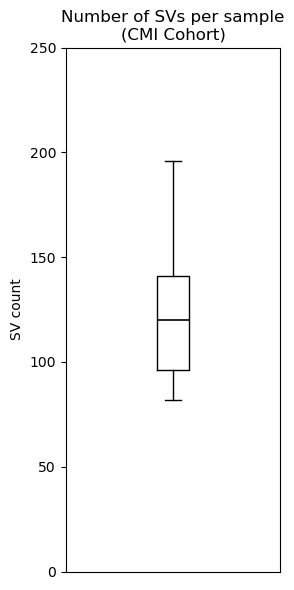

count     10.000000
mean     122.900000
std       35.874627
min       82.000000
25%       96.250000
50%      120.000000
75%      141.250000
max      196.000000
Name: count, dtype: float64

In [ ]:
# Visualize the number of SVs per sample 
svs = pd.read_csv('../../data/cmi_cohort/final_consensus_sv_hg38_filtered.csv')
sv_counts = svs['sample'].value_counts()

plt.figure(figsize=(3, 6))
plt.boxplot(
    sv_counts.values,
    vert=True,
    medianprops=dict(color='black', linewidth=1.2, linestyle='-'),  # black median line
    flierprops=dict(  # outlier style
        marker='o',
        markerfacecolor='black',
        markeredgecolor='none',   # no outline
        markersize=4,
        linestyle='none',
        alpha=1
    )
)
# set max y-axis to 350
plt.ylim(0, 250)

plt.title('Number of SVs per sample\n(CMI Cohort)')
plt.xticks([])
plt.ylabel('SV count')
plt.tight_layout()
plt.show()

sv_counts.describe()


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_9156/3288546341.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


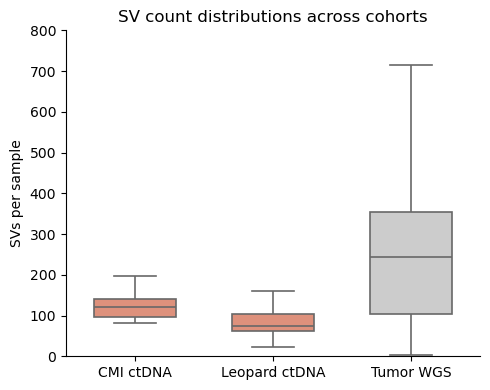

In [ ]:
# boxplots comparing distribution of SV counts across cohorts
svs_cmi = svs.copy()
sv_counts_cmi = svs_cmi['sample'].value_counts()
svs_leopard = pd.read_csv('../../data/leopard_cohort/final_consensus_sv_hg38_filtered.csv')
sv_counts_leopard = svs_leopard['sample'].value_counts()
svs_tumor_wgs = pd.read_csv('../../SV/SV_sample_data/data/sv_file_v2.csv')
final_samples = pd.read_csv('../../SV/SV_sample_data/data/final_samples.csv')
#filter to final samples
svs_tumor_wgs = svs_tumor_wgs[svs_tumor_wgs['name'].isin(final_samples['tumor_normal_pair'])]
sv_counts_tumor_wgs = svs_tumor_wgs['name'].value_counts()

import seaborn as sns

plot_df = pd.concat([
    pd.DataFrame({'cohort': 'CMI ctDNA',      'sv_count': sv_counts_cmi.values}),
    pd.DataFrame({'cohort': 'Leopard ctDNA',  'sv_count': sv_counts_leopard.values}),
    pd.DataFrame({'cohort': 'Tumor WGS',      'sv_count': sv_counts_tumor_wgs.values}),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=plot_df,
    x='cohort',
    y='sv_count',
    showfliers=False,   # hide outliers
    width=0.6,
    linewidth=1.2,
    palette=['#ee876cdb', '#ee876cdb', '#CCCCCC'],
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('SVs per sample')
ax.set_title('SV count distributions across cohorts')
# cap at first and last visible y tick
yt = ax.get_yticks()
ax.set_ylim(0, yt[-1])
ax.spines['left'].set_bounds(0, yt[-1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../outputs/plotting/sv_counts_distribution_across_cohorts.pdf', dpi=300)
plt.show()